In [1]:
import cmdstanpy
cmdstanpy.install_cmdstan()

/media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CmdStan install directory: /home/brasammy/.cmdstan
CmdStan version 2.36.0 already installed
Test model compilation


True

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from loadData import load_data
from imputeMissing import impute_value

import logging
logging.getLogger("cmdstanpy").setLevel(logging.INFO)
from scipy.integrate import odeint

Imputation Done!!!


In [3]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    S, E, I, R = state
    dS = -beta * S * I / N
    dE =  beta * S * I / N - sigma * E
    dI =  sigma * E - gamma * I
    dR =  gamma * I
    return [dS, dE, dI, dR]


In [51]:
# Parameters
n_regions = 3  # Guinea, Liberia, Sierra Leone
T = 450  # Time points (days)
N = [11.5e6, 4.5e6, 6.8e6]  # Population per region
beta = [0.3, 0.4, 0.35]  # Transmission rate (R0 = beta/gamma)
sigma = 1/10  # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/7  # 1/infectious period (Ebola: ~7 days)
phi = 10.0  # Negative binomial dispersion parameter
reporting_rate = 0.8  # Proportion of cases reported

# Initial conditions
guinea = [N[0]-10, 0, 10, 0]
lib = [N[1]-20, 0, 20, 0]
sir = [N[2]-10, 0, 10, 0]

initial_state = [guinea, lib, sir]

# Time vector
t = np.linspace(0, T-1, T)

In [52]:
initial_state

[[11499990.0, 0, 10, 0], [4499980.0, 0, 20, 0], [6799990.0, 0, 10, 0]]

In [53]:
# Simulate SEIR for each region
states = np.zeros((n_regions, T, 4))
incidence = np.zeros((n_regions, T))

for i in range(n_regions):
    # Solve ODE
    sol = odeint(seir, initial_state[i], t, args=(beta[i], sigma, gamma, N[i]))
    states[i] = sol
    # Incidence = new infections = beta * S * I / N
    incidence[i] = beta[i] * sol[:, 0] * sol[:, 2] / N[i]

In [54]:
# Generate observed cases using negative binomial
observed_cases = np.zeros((n_regions, T), dtype=int)
for i in range(n_regions):
    for t in range(T):
        mean_cases = reporting_rate * incidence[i, t]
        # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
        p = phi / (phi + mean_cases)
        r = phi
        observed_cases[i, t] = np.random.negative_binomial(r, p)


In [55]:
# Save data to CSV
# Time vector
t = np.linspace(0, T-1, T)
data = {
    'time': np.tile(t, n_regions),
    'country': np.repeat(['Guinea', 'Liberia', 'Sierra Leone'], T),
    'cases': observed_cases.flatten()
}
df = pd.DataFrame(data)
# df.to_csv('synthetic_ebola_data.csv', index=False)

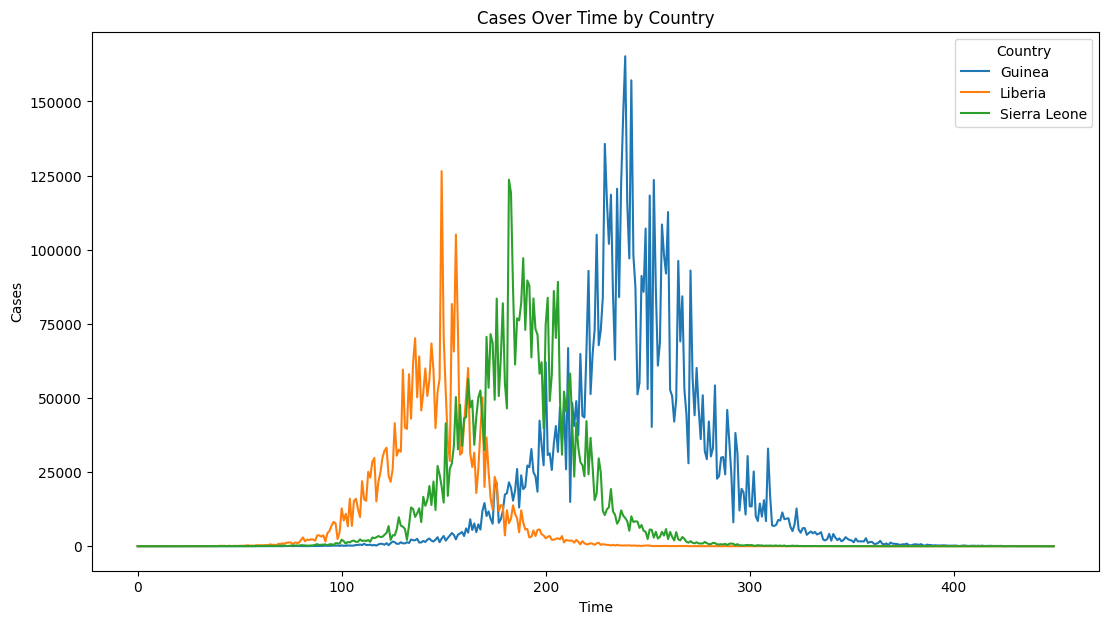

In [56]:
# Group the data by 'country' and plot each group
plt.figure(figsize=(13, 7))
for country, group in df.groupby('country'):
    plt.plot(group['time'], group['cases'], label=country)

# Add labels and legend
plt.xlabel('Time')
plt.ylabel('Cases')
plt.title('Cases Over Time by Country')
plt.legend(title='Country')
plt.show()

In [57]:
# Convert the 'time' column to datetime format, assuming it represents days since 2014-01-01
df["time"] = pd.Timestamp("2014-01-01") + pd.to_timedelta(df["time"], unit="D")

In [58]:
## get patches
patch_names = ["Guinea", "Liberia", "Sierra Leone"]
n_patches = len(patch_names)

# Set the start date to January 1, 2014
start_date =  df["time"].min()
# Calculate the end date from the maximum value in the 'time' column
end_date = df["time"].max()
weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
T = len(weeks)

# Create an empty array to store observed cases
I_obs = np.zeros((T, n_patches))
# country_data = df.copy()

# Fill the observed cases array with weekly data for each patch
for i, country in enumerate(patch_names):
    country_data = df[df["country"] == country]
    # Convert the 'time' column to datetime format
    # country_data["time"] = pd.to_datetime(country_data["time"], unit="D")  # Assuming 'time' is in days
    weekly_cases = country_data.groupby(pd.Grouper(key="time", freq="W-MON"))['cases'].sum()
    # weekly_cases.index = pd.to_datetime(weekly_cases.index)
    weekly_cases = weekly_cases.reindex(weeks, fill_value=0)
    I_obs[:, i] = weekly_cases.values

# Create a DataFrame for plotting
time = np.arange(1, T + 1)
data_plot = pd.DataFrame(I_obs, columns=patch_names)
data_plot["Time"] = time
data_plot["Week"] = weeks[:].strftime("%Y-%m-%d")
# Melt the DataFrame for easier plotting
data_plot = data_plot.melt(id_vars=["Time", "Week"], var_name="Patches", value_name="Cases")

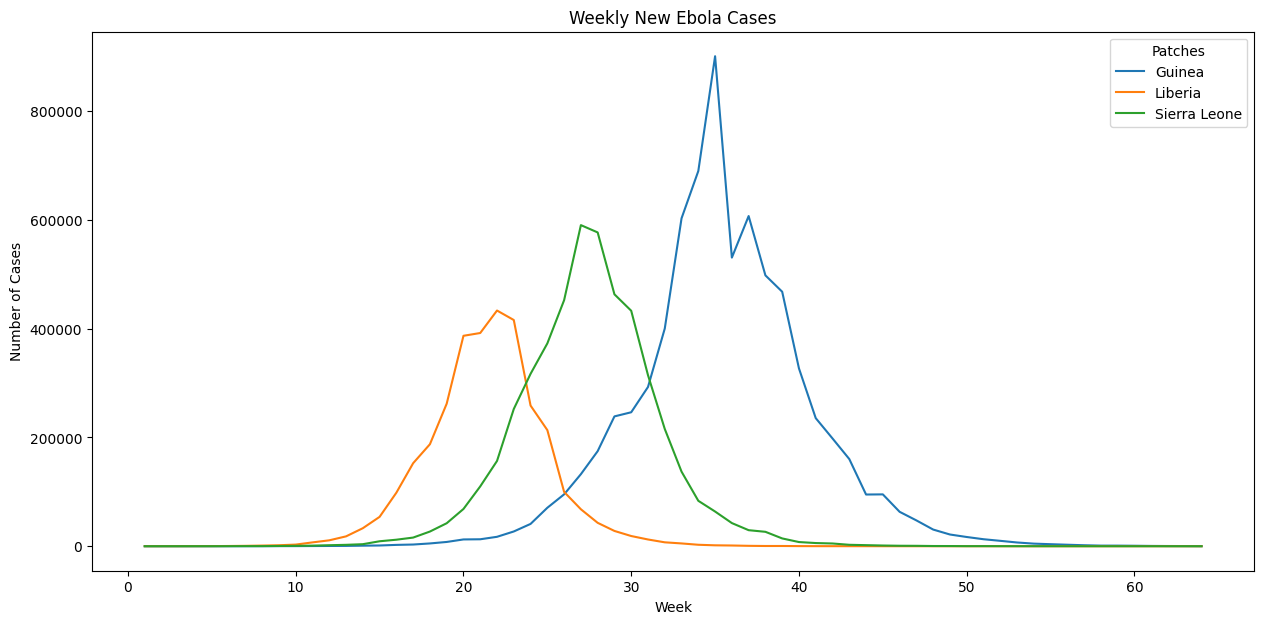

In [59]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=data_plot, x="Time", y="Cases", hue="Patches")
plt.title("Weekly New Ebola Cases")
plt.xlabel("Week")
plt.ylabel("Number of Cases")
# plt.grid(True)
plt.savefig('./images/weekly_cases.pdf', bbox_inches='tight')
plt.show()

In [60]:
# Population sizes (approximate, in millions)
n = np.array([11.5e6, 4.5e6, 6.8e6])  # Guinea, Liberia, Sierra Leone

N = np.sum(n)  # Total population

In [75]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases = weekly_cases.reindex(columns=countries, fill_value=0)
cases = weekly_cases.values  # Shape: (T, 3)

data = {
    'P': 3,
    'T': len(cases),
    't0': -1e-3,
    'ts': np.arange(len(cases)),
    'cases': cases,
    'N': [11500000, 4500000, 6800000],
    # 'N': [30000, 500000, 25000]  # Effective population
    'E0': [0, 2, 0],
    'I0': [10, 20, 10]
}

print("Cases shape:", cases.shape)
print("Cases shape:", data_plot.shape)
print("\nFirst few weeks:\n", cases)

Cases shape: (65, 3)
Cases shape: (192, 4)

First few weeks:
 [[     6     22     15]
 [    17     36     17]
 [    17     67     25]
 [    18    134     47]
 [    30    187     51]
 [    50    336     91]
 [    61    729    168]
 [   102    943    202]
 [   139   1843    399]
 [   198   2906    744]
 [   312   6137    985]
 [   476  10481   1800]
 [   604  16082   2347]
 [   887  28594   3760]
 [  1310  55463   8094]
 [  2335  83179  11642]
 [  3262 159443  14662]
 [  4317 180895  27844]
 [  7883 243742  38538]
 [ 12182 362856  61543]
 [ 12450 396635 100957]
 [ 16115 456954 161607]
 [ 25102 420087 235523]
 [ 41067 272131 307033]
 [ 66198 215268 345061]
 [ 87204 112331 468777]
 [136818  66905 569234]
 [162911  42412 569474]
 [232865  30221 462906]
 [241629  18497 485778]
 [279175  13675 303860]
 [397780   8312 220564]
 [518435   5599 163173]
 [741507   2900  85296]
 [886759   1755  64325]
 [575690   1276  48294]
 [551508    868  27073]
 [556846    507  26572]
 [424519    417  17392]
 [

In [64]:
# Compile and fit the model
model_synth = CmdStanModel(stan_file="multi_patch.stan")
fit_synth = model_synth.sample(
    data=data,
    chains=4,
    iter_warmup= 500,
    iter_sampling=1000,
    seed=12
)
# Convert to ArviZ InferenceData for analysis
inference_data = az.from_cmdstanpy(fit_synth)

12:42:35 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▌         | 00:13 Status


chain 1 |███████   | 05:28 Iteration:  900 / 1500 [ 60%]  (Sampling)

chain 1 |████████▏ | 06:03 Iteration: 1100 / 1500 [ 73%]  (Sampling)

chain 1 |█████████▍| 06:30 Iteration: 1300 / 1500 [ 86%]  (Sampling)


chain 1 |██████████| 06:47 Iteration: 1400 / 1500 [ 93%]  (Sampling)








































chain 1 |██████████| 53:32 Sampling completed                       
chain 2 |██████████| 53:32 Sampling completed                       
chain 3 |██████████| 53:32 Sampling completed                       
chain 4 |██████████| 53:32 Sampling completed                       


13:36:08 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
13:36:08 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_lpmf: Location parameter[29] is -1.89645e-08, but must be positive finite! (in 'multi_patch.stan', line 101, column 4 to column 55)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode_rk45: ode parameters and data[4] is inf, but must be finite! (in 'multi_patch.stan', line 74, column 4 to column 81)
	Exception: ode

In [65]:
print(fit_synth.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.01, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  sigma, gamma, beta[1], beta[2], beta[3], phi_inv, rho[1], rho[2], incidence[1,1], incidence[2,1], incidence[3,1], incidence[4,1], incidence[5,1], incidence[6,1], incidence[7,1], incidence[8,1], incidence[9,1], incidence[10,1], incidence[11,1], incidence[12,1], incidence[13,1], incidence[14,1], incidence[15,1], incidence[16,1], incidence[17,1], incidence[18,1], incidence[19,1], incidence[20,1], incidence[21,1], incidence[22,1], incidence

In [66]:
fit_synth.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-2236.090000,39.225500,55.592100,17.806000,-2278.280000,-2267.470000,-2139.38000,5.26717,2000.0000,2.10202
sigma,1.870610,1.010710,1.451670,1.434970,0.438503,1.389830,3.95221,5.70602,2000.0000,1.88380
gamma,0.284215,0.224574,0.318381,0.132228,0.034412,0.134011,0.85330,4.89147,2000.0000,2.41528
beta[1],0.996743,0.218752,0.310804,0.310479,0.493534,1.062240,1.37722,4.89412,2000.0000,2.41706
beta[2],1.600570,0.360790,0.513713,0.343911,0.726050,1.751410,2.08462,5.26025,2000.0000,2.24690
...,...,...,...,...,...,...,...,...,...,...
"predicted_cases[64,2]",0.037500,NaN,0.192621,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN
"predicted_cases[64,3]",2.711500,0.812306,2.635050,1.482600,0.000000,2.000000,8.00000,19.80640,43.4156,1.13869
"predicted_cases[65,1]",206.803000,21.756200,122.868000,81.543000,63.000000,175.000000,449.05000,245.48900,2000.0000,1.13920
"predicted_cases[65,2]",0.034750,NaN,0.191185,0.000000,0.000000,0.000000,0.00000,813.61700,1565.0200,1.01717


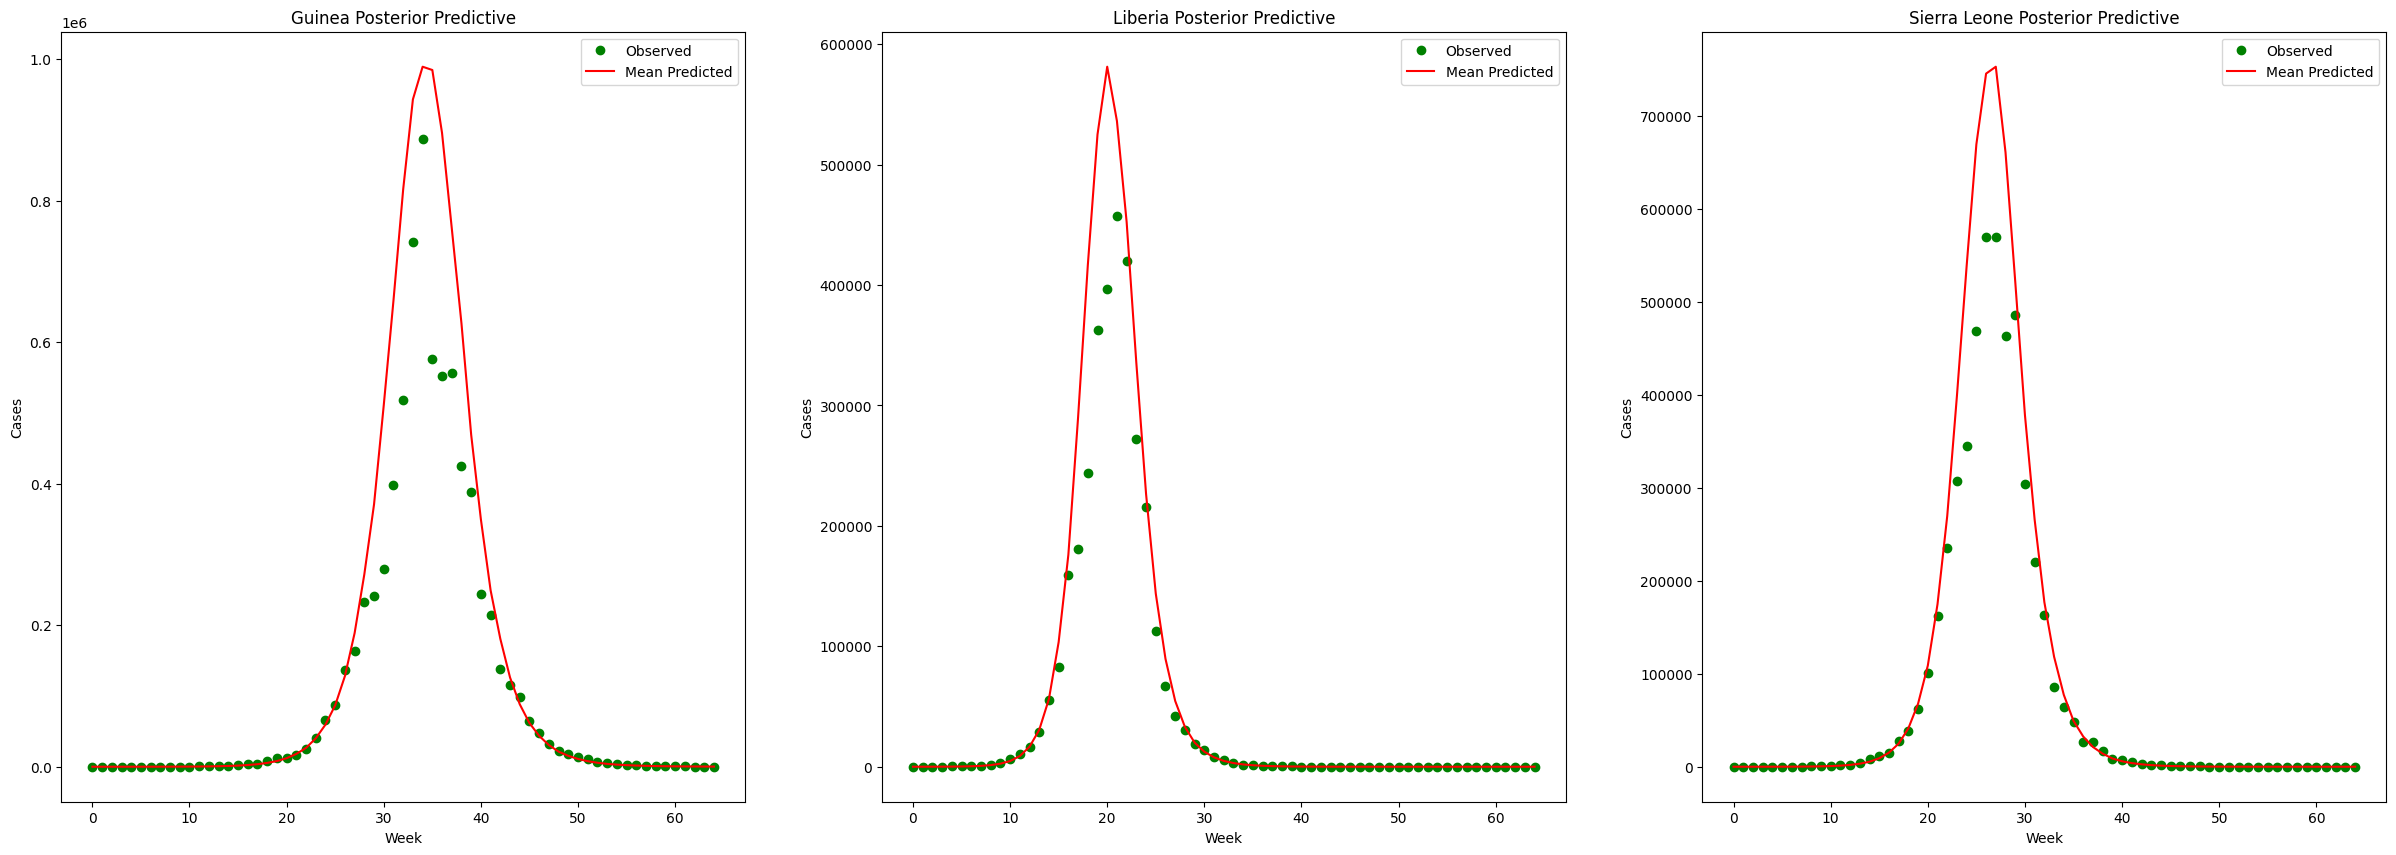

In [67]:
import matplotlib.pyplot as plt
predicted_cases = fit_synth.stan_variable('predicted_cases')  # Shape: (samples, T, P)

## subplot (1,3)
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
for p, country in enumerate(countries):
    # for i in range(400):
    #     plt.plot(data['ts'], predicted_cases[i, :, p], alpha=0.1, color='blue')
    axes[p].plot(data['ts'], data['cases'][:, p], 'o', label='Observed', color='green')
    axes[p].plot(data['ts'], predicted_cases.mean(axis=0)[:, p], label='Mean Predicted', color='red')
    axes[p].set_title(f'{country} Posterior Predictive')
    axes[p].set_xlabel('Week')
    axes[p].set_ylabel('Cases')
    axes[p].legend()
plt.show()

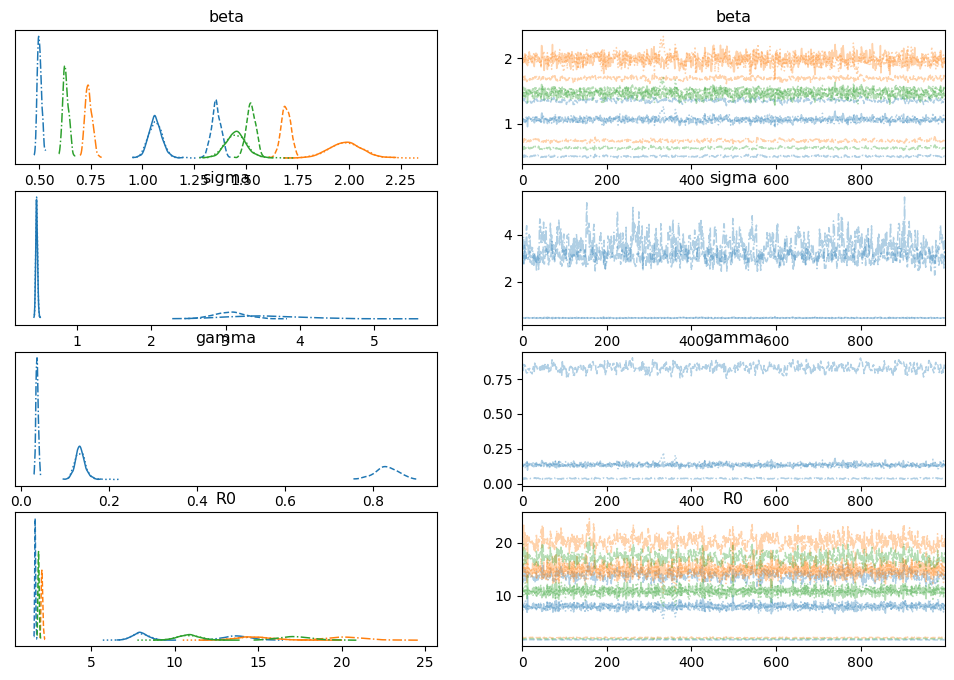

In [68]:
## trace plots
az.plot_trace(fit_synth, var_names=["beta", "sigma", "gamma", "R0"])
plt.show()

# Posterior Predictive Checks

Available variables: dict_keys(['sigma', 'gamma', 'beta', 'phi_inv', 'rho', 'incidence', 'phi', 'theta', 'R0', 'predicted_cases'])


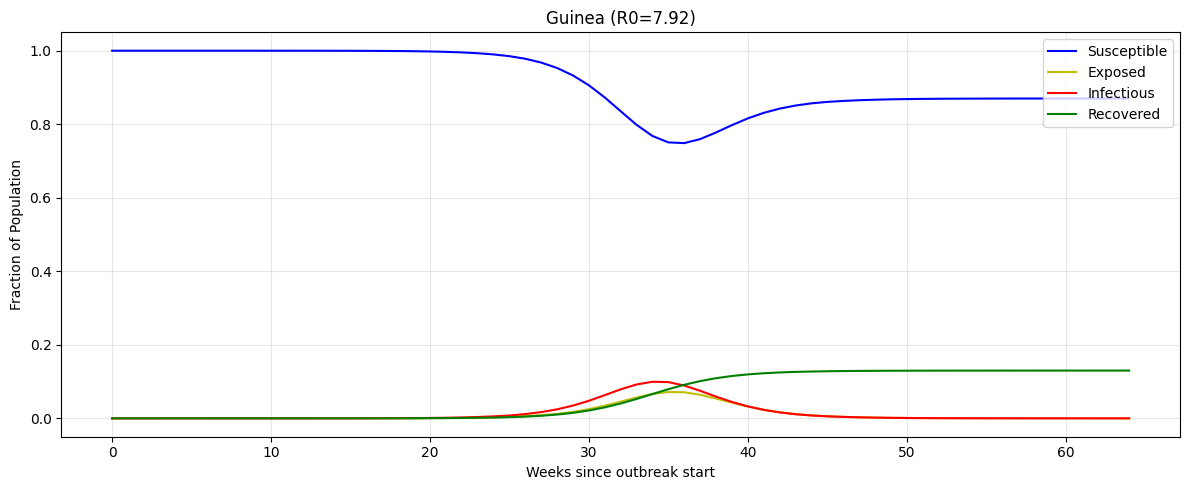

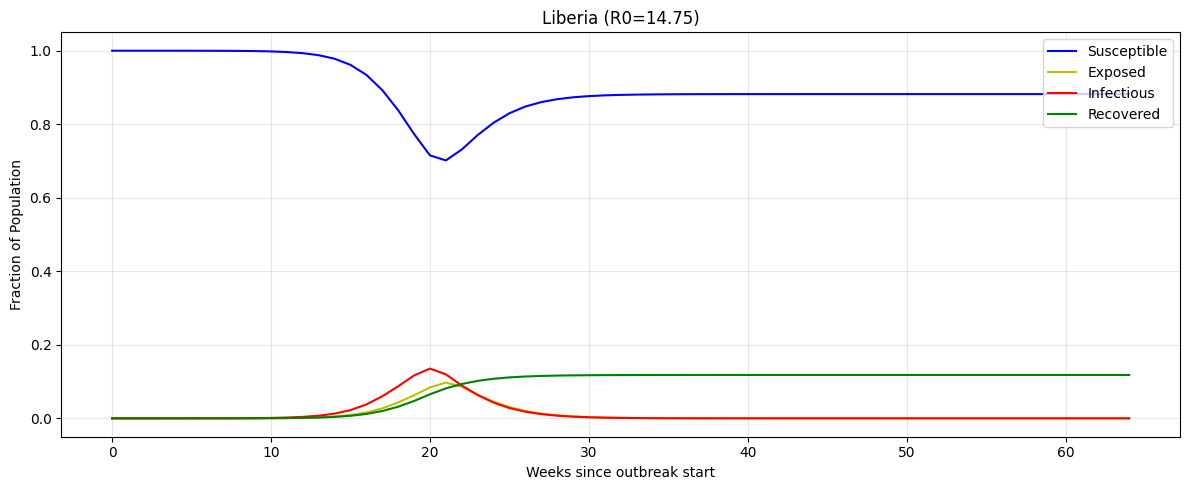

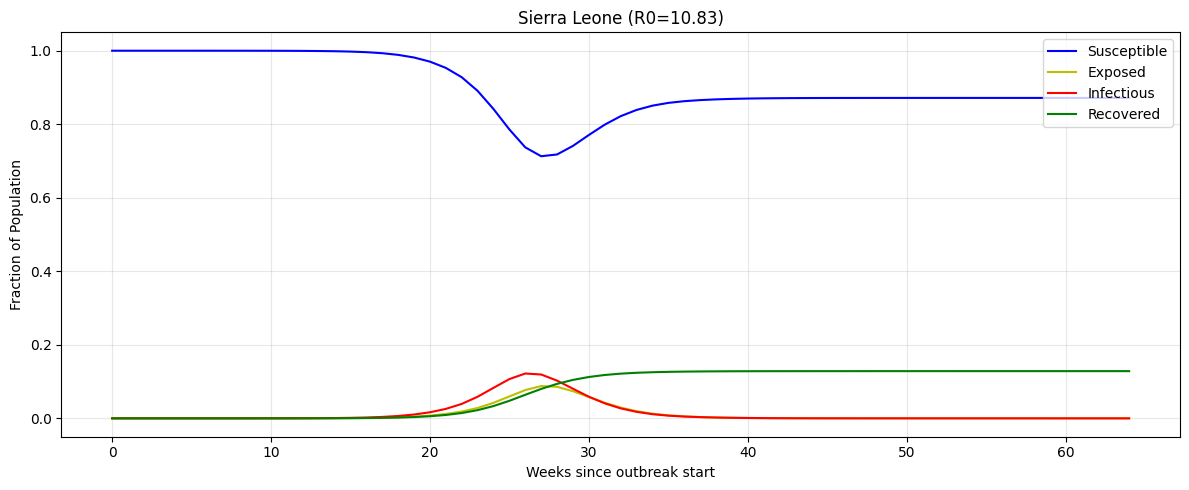

In [74]:
# Get available variables
print("Available variables:", fit_synth.stan_variables().keys())

# Time points and countries
weeks = np.arange(fit_synth.stan_variable('incidence').shape[1])  # Number of weeks
countries = ['Guinea', 'Liberia', 'Sierra Leone']



# Plot incidence (infectious) and reconstructed other compartments
for i, (country) in enumerate(countries):
    
    # Create figure
    fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
        # Get median incidence
    incidence = np.median(fit_synth.stan_variable('incidence')[:, :, i], axis=0)
    
    # Reconstruct approximate compartments (scaled by reporting rate)
    rho = np.median(fit_synth.stan_variable('rho')[:, i])
    I = incidence / rho
    R = np.cumsum(I) * np.median(fit_synth.stan_variable('gamma'))
    E = np.roll(I, 1) / np.median(fit_synth.stan_variable('sigma'))  # Exposed ~ delayed infectious
    E[0] = 0
    S = data['N'][i] - E - I - R
    
    # Convert to fractions
    S_frac = S / data['N'][i]
    E_frac = E / data['N'][i]
    I_frac = I / data['N'][i]
    R_frac = R / data['N'][i]
    
    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')
    
    # Formatting
    plt.title(f'{country} (R0={np.median(fit_synth.stan_variable("R0")[:, i]):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)
    
    plt.legend(loc='upper right')

    plt.xlabel('Weeks since outbreak start')
    plt.tight_layout()
    plt.show()

In [82]:
# p = fit_synth.summary()
# p.filter(like="y_pred", axis=0)

In [ ]:
# Compile and fit the model
model_coupling = CmdStanModel(stan_file="patch_with_coupling.stan")
fit_coupling = model_coupling.sample(
    data=data,
    chains=4,
    iter_warmup= 500,
    iter_sampling=1000,
    threads_per_chain=2,
    seed=12
)
# Convert to ArviZ InferenceData for analysis
inference_data = az.from_cmdstanpy(fit_coupling)

21:50:32 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing


















































